C:\Users\bmanna\AppData\Local\Temp\ipykernel_1620\323989368.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


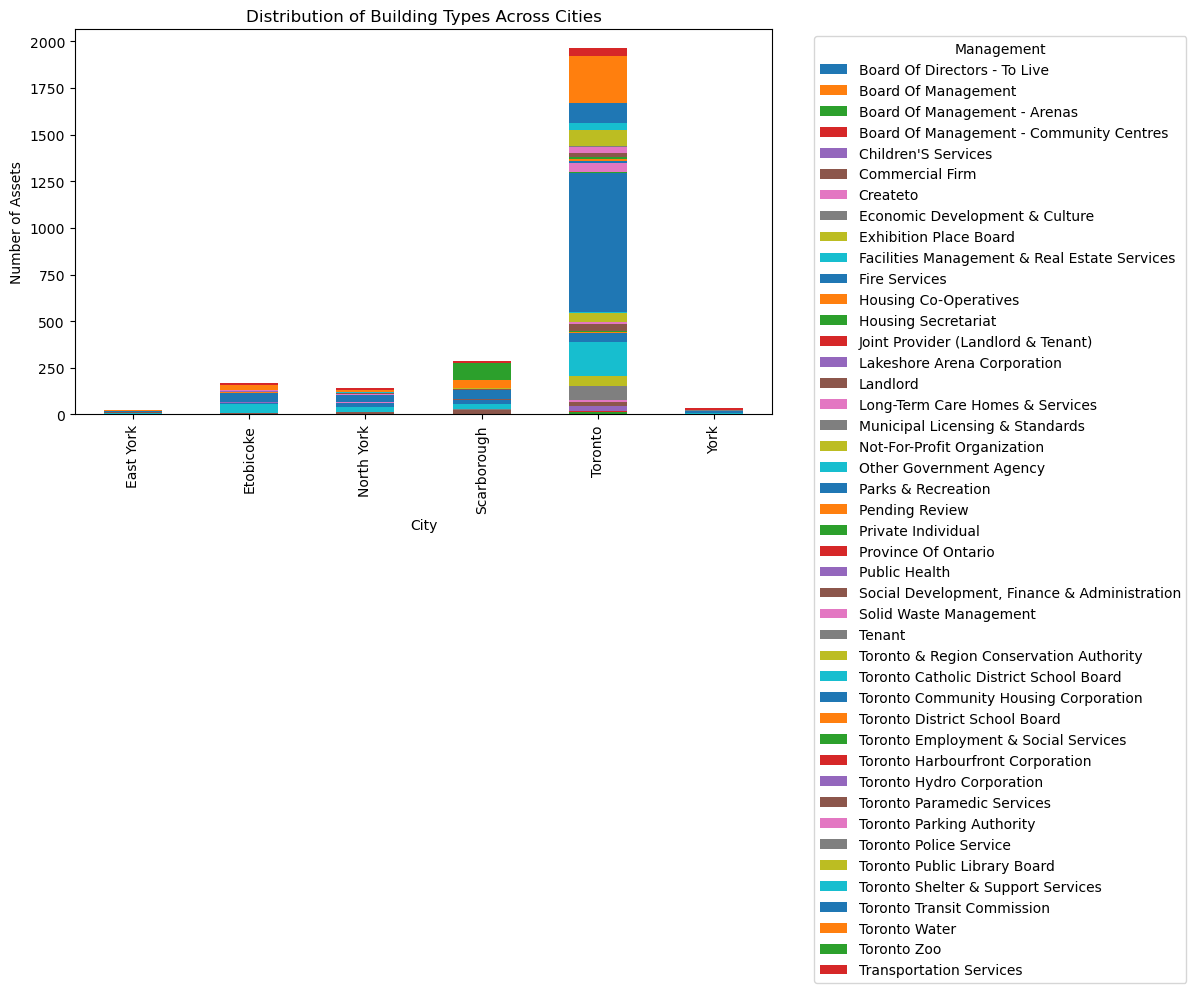

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Fetch dataset metadata
api_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca/api/3/action/package_show"
resp = requests.get(api_url, params={"id": "real-estate-asset-inventory"})
resp.raise_for_status()
metadata = resp.json()["result"]

# Step 2: Locate the CSV resource
resources = metadata["resources"]
csv_res = next(r for r in resources if r["format"].lower() == "csv" and "building-asset-inventory" in r["name"])
csv_url = csv_res["url"]
#print("Loading CSV from:", csv_url)

# Step 3: Load data into DataFrame
df = pd.read_csv(csv_url, usecols=["Management", "City"])
df = df.dropna(subset=["Management", "City"])

# Optional: Normalize names
df["Management"] = df["Management"].str.strip().str.title()
df["City"] = df["City"].str.strip().str.title()

# Step 4: Create pivot for counts
pivot = df.groupby(["City", "Management"]).size().unstack(fill_value=0)

# Optional: focus on top N building types to simplify chart
#top_types = pivot.sum().nlargest(6).index
#pivot = pivot[top_types]

# Step 5: Plot stacked bar chart
pivot.plot(kind="bar", stacked=True, figsize=(9, 5), width=0.5)
plt.title("Distribution of Building Types Across Cities")
plt.xlabel("City")
plt.ylabel("Number of Assets")
plt.legend(title="Management", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
#plt.show()
